### comparing different models 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [3]:
# Load dataset
df = pd.read_csv('Social_Network_Ads.csv')

# Optional: Encode Gender column if using it
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Features and target
X = df[['Age', 'EstimatedSalary']]  # or include 'Gender' too
y = df['Purchased']


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

C:\Users\maahi\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:37:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


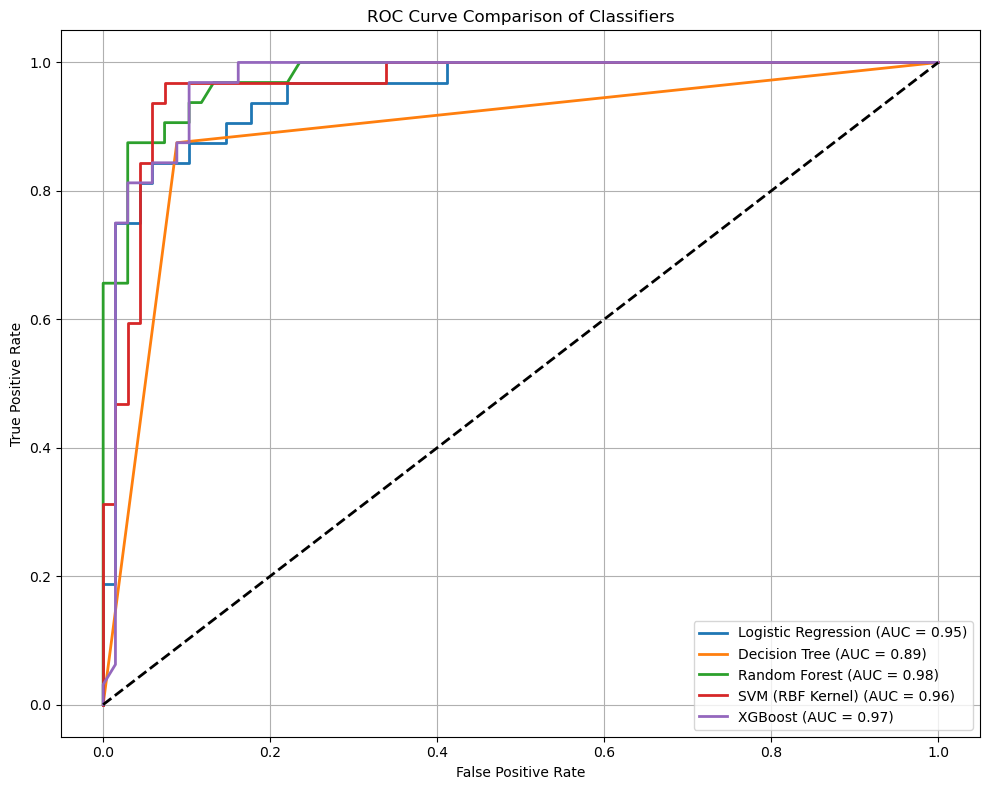

In [5]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=0),
    'SVM (RBF Kernel)': SVC(probability=True, kernel='rbf', random_state=0),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Plotting ROC Curve
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Get predicted probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:  # For SVM with no predict_proba
        y_proba = model.decision_function(X_test)

    # Calculate ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Final plot formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Classifiers')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()
